## PREPARACION DE DATOS

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error 
from sklearn.preprocessing import StandardScaler    
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


In [2]:
# cargar dataset pandas as pd
df = pd.read_csv('car_data.csv')
df.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17


In [3]:
# Información del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Mileage            354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  NotRepaired        283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

In [4]:
# estadísticas descriptivas del DataFrame
df.describe()

,Price,RegistrationYear,Power,Mileage,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


In [5]:
df['DateCrawled'] = pd.to_datetime(df['DateCrawled'],errors='coerce')
df['LastSeen'] = pd.to_datetime(df['LastSeen'],errors='coerce')
df['DateCreated'] = pd.to_datetime(df['DateCreated'],errors='coerce')


/var/folders/b2/x1k3dmls1d9_8l8pvzdps0080000gn/T/ipykernel_3710/3545512776.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['DateCrawled'] = pd.to_datetime(df['DateCrawled'],errors='coerce')
/var/folders/b2/x1k3dmls1d9_8l8pvzdps0080000gn/T/ipykernel_3710/3545512776.py:3: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['DateCreated'] = pd.to_datetime(df['DateCreated'],errors='coerce')


In [6]:
# se convierten las columnas en minusculas
df.columns = df.columns.str.lower()

In [7]:
# se eliminan los espacios en blanco de los nombres de las columnas
df.columns = df.columns.str.strip()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   datecrawled        354369 non-null  datetime64[ns]
 1   price              354369 non-null  int64         
 2   vehicletype        316879 non-null  object        
 3   registrationyear   354369 non-null  int64         
 4   gearbox            334536 non-null  object        
 5   power              354369 non-null  int64         
 6   model              334664 non-null  object        
 7   mileage            354369 non-null  int64         
 8   registrationmonth  354369 non-null  int64         
 9   fueltype           321474 non-null  object        
 10  brand              354369 non-null  object        
 11  notrepaired        283215 non-null  object        
 12  datecreated        354369 non-null  datetime64[ns]
 13  numberofpictures   354369 non-null  int64   

In [9]:
# se revisan los valores nulos en porcentaje 
df.isnull().sum() / len(df) * 100

datecrawled           0.000000
price                 0.000000
vehicletype          10.579368
registrationyear      0.000000
gearbox               5.596709
power                 0.000000
model                 5.560588
mileage               0.000000
registrationmonth     0.000000
fueltype              9.282697
brand                 0.000000
notrepaired          20.079070
datecreated           0.000000
numberofpictures      0.000000
postalcode            0.000000
lastseen             35.617675
dtype: float64

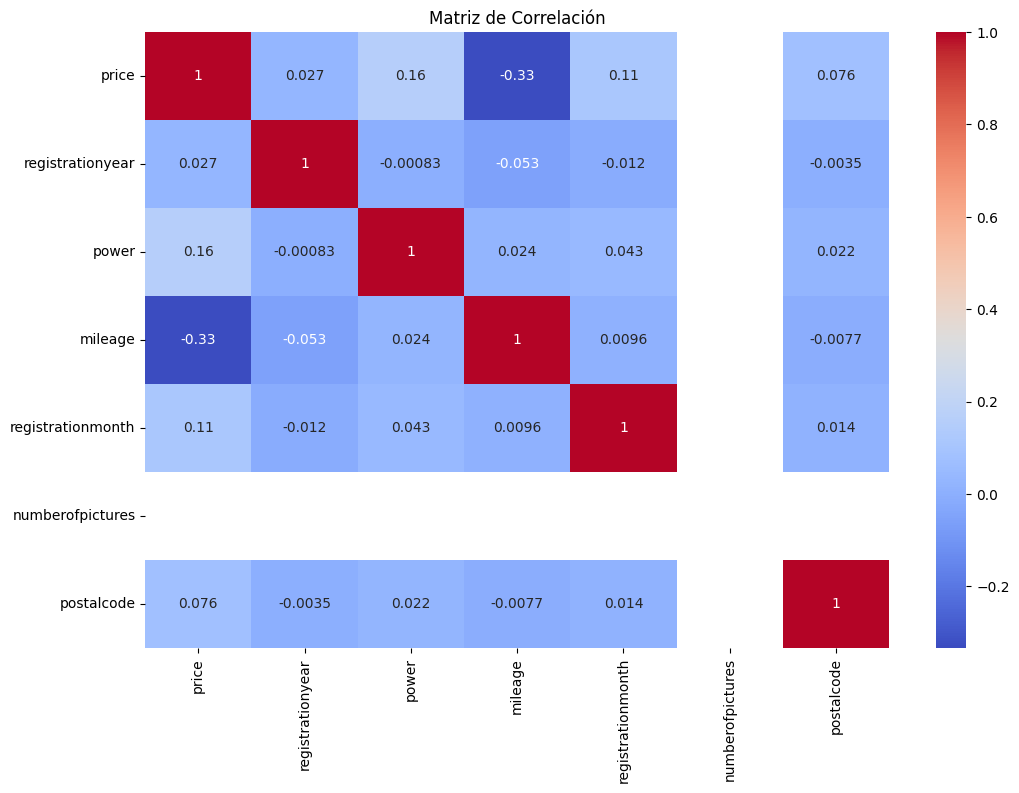

In [10]:
# se crea una matrix de correlacion
numeric_df = df.select_dtypes(include=['int64'])

plt.figure(figsize=(12,8))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

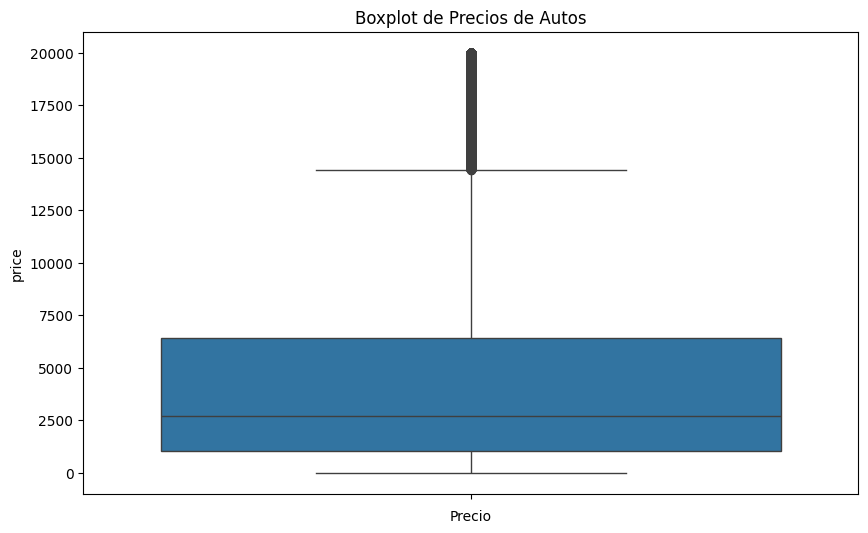

In [11]:
# se graficia boxplot de precio para analizar outliers
plt.figure(figsize=(10,6))
sns.boxplot(df['price'])
plt.title('Boxplot de Precios de Autos')
plt.xlabel('Precio')
plt.show()     

In [12]:
# se inspeccionan los autos con precio mayor a 15000
high_prices = df[df['price'] >= 15000].sort_values(by='price', ascending=False)
high_prices.head()

,datecrawled,price,vehicletype,registrationyear,gearbox,power,model,mileage,registrationmonth,fueltype,brand,notrepaired,datecreated,numberofpictures,postalcode,lastseen
105236,2016-03-12 10:58:00,20000,sedan,2012,manual,143,3er,60000,0,gasoline,bmw,no,2016-03-12,0,36396,2016-06-04 02:46:00
317397,2016-03-31 19:53:00,20000,coupe,1970,NaN,0,other,40000,0,petrol,alfa_romeo,NaN,2016-03-31,0,30159,NaT
190812,2016-03-26 20:57:00,20000,wagon,2008,auto,232,a6,150000,4,gasoline,audi,no,2016-03-26,0,93336,2016-06-04 11:45:00
189783,2016-03-29 16:47:00,20000,NaN,2010,NaN,0,x_reihe,100000,9,NaN,bmw,NaN,2016-03-29,0,78652,NaT
313338,2016-03-07 20:36:00,20000,coupe,2008,manual,313,other,70000,2,petrol,nissan,no,2016-03-07,0,18109,2016-08-03 19:22:00


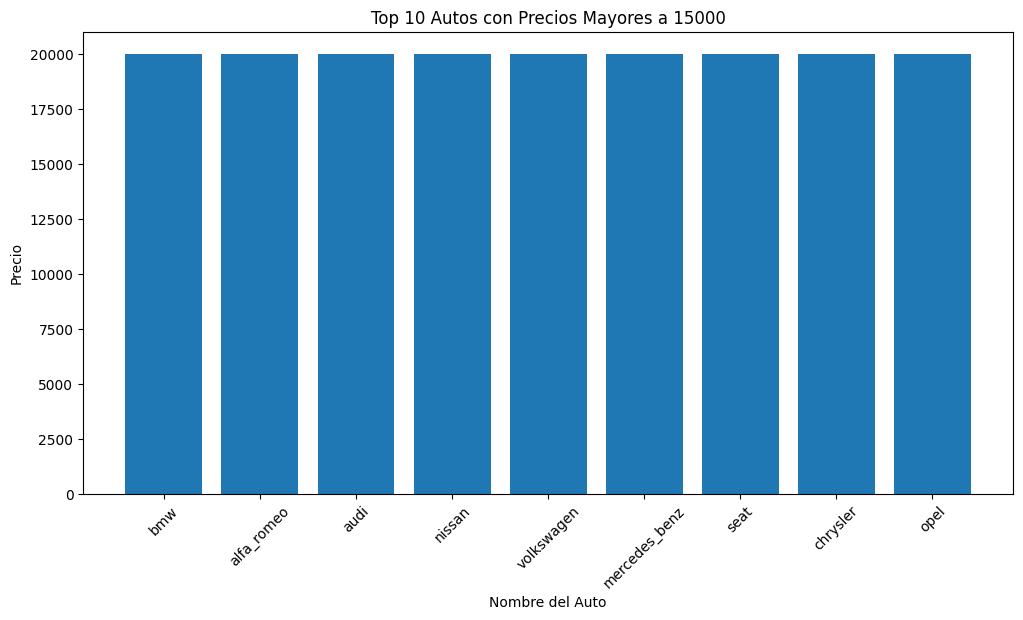

In [13]:
# grafico de barras de los autos con precios mayores a 15000
plt.figure(figsize=(12,6))
plt.bar(high_prices['brand'].head(20), high_prices['price'].head(20))
plt.title('Top 10 Autos con Precios Mayores a 15000')
plt.xlabel('Nombre del Auto')
plt.ylabel('Precio')
plt.xticks(rotation=45)
plt.show()


Se grafican las marcas mas costosas de carros, esto puede ayudar a idenficar clientes de mayor valor, para realizar campañas de marketing enfocadas en este tipo de marcas.

In [14]:
# los valores nulos se manejan llenando la informacion como 'unknown'
df.fillna('unknown', inplace=True)  
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   datecrawled        354369 non-null  datetime64[ns]
 1   price              354369 non-null  int64         
 2   vehicletype        354369 non-null  object        
 3   registrationyear   354369 non-null  int64         
 4   gearbox            354369 non-null  object        
 5   power              354369 non-null  int64         
 6   model              354369 non-null  object        
 7   mileage            354369 non-null  int64         
 8   registrationmonth  354369 non-null  int64         
 9   fueltype           354369 non-null  object        
 10  brand              354369 non-null  object        
 11  notrepaired        354369 non-null  object        
 12  datecreated        354369 non-null  datetime64[ns]
 13  numberofpictures   354369 non-null  int64   

/var/folders/b2/x1k3dmls1d9_8l8pvzdps0080000gn/T/ipykernel_3710/1209772884.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'unknown' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df.fillna('unknown', inplace=True)


In [15]:
# se guarda una copia del dataframe original
df_original = df.copy()

In [16]:
# se eliminan columnas irrelevantes
df_modified = df.drop(columns=['datecrawled', 'datecreated', 'lastseen', 'postalcode', 'numberofpictures','registrationmonth'])
df_modified.head()

,price,vehicletype,registrationyear,gearbox,power,model,mileage,fueltype,brand,notrepaired
0,480,unknown,1993,manual,0,golf,150000,petrol,volkswagen,unknown
1,18300,coupe,2011,manual,190,unknown,125000,gasoline,audi,yes
2,9800,suv,2004,auto,163,grand,125000,gasoline,jeep,unknown
3,1500,small,2001,manual,75,golf,150000,petrol,volkswagen,no
4,3600,small,2008,manual,69,fabia,90000,gasoline,skoda,no


In [17]:
# se revisan los valores unicos en cada columna del dataframe modificado
df_modified.nunique()

price               3731
vehicletype            9
registrationyear     151
gearbox                3
power                712
model                251
mileage               13
fueltype               8
brand                 40
notrepaired            3
dtype: int64

Se evidencia que hay 251 categorias en la variable model, y 40 en la variable brand, por lo que se agrupan las variables dentro de un grupo de mayor relevancia y evitar un sobre dimensionamiento del dataset. 

In [18]:
df_modified['model'].value_counts() / len(df_modified) * 100


model
golf                  8.249029
other                 6.891404
3er                   5.576391
unknown               5.560588
polo                  3.687117
                        ...   
i3                    0.002258
serie_3               0.001129
rangerover            0.001129
range_rover_evoque    0.000564
serie_1               0.000564
Name: count, Length: 251, dtype: float64

El porcentaje desconocido del modelo de vehiculo es no mayor al 6%, se decide eliminar estos valores para realizar un mejor filtro de la informacion. 

In [19]:
# se eliminan los valores 'uknown' en la columna model
df_modified.drop(df_modified[df_modified['model'] == 'unknown'].index, inplace=True)

In [20]:
df_modified['model'].value_counts() / len(df_modified) * 100

model
golf                  8.734731
other                 7.297170
3er                   5.904728
polo                  3.904214
corsa                 3.756006
                        ...   
i3                    0.002390
serie_3               0.001195
rangerover            0.001195
range_rover_evoque    0.000598
serie_1               0.000598
Name: count, Length: 250, dtype: float64

In [21]:
df_modified['brand'].value_counts() / len(df_modified) * 100

brand
volkswagen       21.964717
opel             11.372601
bmw              10.451976
mercedes_benz     9.214018
audi              8.418294
ford              7.220974
renault           5.137093
peugeot           3.020044
fiat              2.731396
seat              1.993641
skoda             1.601308
mazda             1.572622
smart             1.487462
citroen           1.463856
nissan            1.414553
toyota            1.329393
hyundai           1.003693
mini              0.938254
volvo             0.926601
mitsubishi        0.855186
honda             0.795425
kia               0.702794
suzuki            0.653192
alfa_romeo        0.650503
chevrolet         0.491239
chrysler          0.403390
dacia             0.262353
daihatsu          0.229185
subaru            0.214544
porsche           0.213946
jeep              0.194523
land_rover        0.158965
saab              0.152392
daewoo            0.148208
trabant           0.147611
jaguar            0.146714
lancia            0.13

In [22]:
df_modified.info()

<class 'pandas.core.frame.DataFrame'>
Index: 334664 entries, 0 to 354368
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   price             334664 non-null  int64 
 1   vehicletype       334664 non-null  object
 2   registrationyear  334664 non-null  int64 
 3   gearbox           334664 non-null  object
 4   power             334664 non-null  int64 
 5   model             334664 non-null  object
 6   mileage           334664 non-null  int64 
 7   fueltype          334664 non-null  object
 8   brand             334664 non-null  object
 9   notrepaired       334664 non-null  object
dtypes: int64(4), object(6)
memory usage: 28.1+ MB


In [23]:
df_modified.isnull().sum()

price               0
vehicletype         0
registrationyear    0
gearbox             0
power               0
model               0
mileage             0
fueltype            0
brand               0
notrepaired         0
dtype: int64

In [24]:
# se seleccionan las características y la variable objetivo
X = df_modified.drop('price', axis=1)
y = df_modified['price']    


In [25]:
# se divide el dataset en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [26]:
# se agrupan las categorias de la columnas 'brand' y 'model' que representan menos del 1% de los datos en una categoria llamada 'other' 
for col in ['brand', 'model']:
    value_counts = X_train[col].value_counts(normalize=True)
    to_replace = value_counts[value_counts < 0.01].index
    X_train[col] = X_train[col].replace(to_replace, 'other')
    X_test[col] = X_test[col].replace(to_replace, 'other')
    
    



In [27]:
X_train['brand'].value_counts()

brand
volkswagen       58788
opel             30431
bmw              28011
mercedes_benz    24639
other            23027
audi             22520
ford             19355
renault          13853
peugeot           8086
fiat              7292
seat              5281
skoda             4252
mazda             4166
smart             3999
citroen           3969
nissan            3791
toyota            3542
hyundai           2729
Name: count, dtype: int64

In [28]:
X_test['brand'].value_counts()

brand
volkswagen       14720
opel              7629
bmw               6968
mercedes_benz     6197
other             5762
audi              5653
ford              4811
renault           3339
peugeot           2021
fiat              1849
seat              1391
skoda             1107
mazda             1097
smart              979
nissan             943
citroen            930
toyota             907
hyundai            630
Name: count, dtype: int64

In [29]:
X_train['model'].value_counts()

model
other          110343
golf            23387
3er             15823
polo            10428
corsa           10016
astra            8664
passat           8072
a4               7883
c_klasse         6665
5er              6309
e_klasse         5414
a3               4912
focus            4723
fiesta           4668
a6               4465
twingo           3989
transporter      3868
2_reihe          3804
fortwo           3483
vectra           3376
a_klasse         3331
mondeo           2876
1er              2836
clio             2814
3_reihe          2792
touran           2790
Name: count, dtype: int64

In [30]:
X_test['model'].value_counts()

model
other          27562
golf            5845
3er             3938
polo            2638
corsa           2554
astra           2145
passat          2074
a4              2017
c_klasse        1647
5er             1559
e_klasse        1371
a3              1210
focus           1151
fiesta          1106
a6              1076
2_reihe         1012
twingo           964
transporter      954
vectra           878
a_klasse         862
fortwo           854
clio             732
mondeo           725
3_reihe          701
touran           680
1er              678
Name: count, dtype: int64

In [31]:
X_train

,vehicletype,registrationyear,gearbox,power,model,mileage,fueltype,brand,notrepaired
137282,sedan,2005,manual,75,golf,150000,petrol,volkswagen,no
35387,sedan,2003,manual,125,mondeo,150000,petrol,ford,no
199049,small,2010,manual,133,twingo,70000,petrol,renault,no
335644,wagon,2001,auto,143,c_klasse,150000,gasoline,mercedes_benz,no
177850,wagon,2004,manual,101,focus,150000,petrol,ford,no
...,...,...,...,...,...,...,...,...,...
126932,sedan,2006,manual,86,clio,125000,gasoline,renault,no
274551,small,2009,manual,68,other,150000,lpg,peugeot,no
139678,wagon,1996,manual,90,passat,150000,petrol,volkswagen,no
155527,small,1997,manual,60,fiesta,150000,petrol,ford,no


In [32]:
# se aplica OneHotEncoder a las columnas categóricas
categorical_cols = ['brand', 'model', 'fueltype', 'vehicletype', 'gearbox','notrepaired']   
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train[categorical_cols])





,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [33]:
X_train_encoded = pd.DataFrame(encoder.transform(X_train[categorical_cols]), columns=encoder.get_feature_names_out(categorical_cols), index=X_train.index)
X_test_encoded = pd.DataFrame(encoder.transform(X_test[categorical_cols]), columns=encoder.get_feature_names_out(categorical_cols), index=X_test.index) 
X_train_encoded


,brand_audi,brand_bmw,brand_citroen,brand_fiat,brand_ford,brand_hyundai,brand_mazda,brand_mercedes_benz,brand_nissan,brand_opel,...,vehicletype_small,vehicletype_suv,vehicletype_unknown,vehicletype_wagon,gearbox_auto,gearbox_manual,gearbox_unknown,notrepaired_no,notrepaired_unknown,notrepaired_yes
137282,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
35387,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
199049,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
335644,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
177850,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126932,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
274551,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
139678,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
155527,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [34]:
# se seleccionan las columnas numéricas
numerical_cols = X_train[['registrationyear','power','mileage',]]

In [35]:
# se concatenan las columnas numéricas y las columnas codificadas
X_train_final = pd.concat([X_train_encoded, numerical_cols], axis=1)
X_test_final = pd.concat([X_test_encoded, X_test[numerical_cols.columns]], axis=1) # se asegura que las columnas numéricas del conjunto de prueba coincidan con las del conjunto de entrenamiento


In [36]:
X_train_final

,brand_audi,brand_bmw,brand_citroen,brand_fiat,brand_ford,brand_hyundai,brand_mazda,brand_mercedes_benz,brand_nissan,brand_opel,...,vehicletype_wagon,gearbox_auto,gearbox_manual,gearbox_unknown,notrepaired_no,notrepaired_unknown,notrepaired_yes,registrationyear,power,mileage
137282,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2005,75,150000
35387,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2003,125,150000
199049,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2010,133,70000
335644,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,2001,143,150000
177850,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,2004,101,150000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126932,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2006,86,125000
274551,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2009,68,150000
139678,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1996,90,150000
155527,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1997,60,150000


In [37]:
X_test_final


,brand_audi,brand_bmw,brand_citroen,brand_fiat,brand_ford,brand_hyundai,brand_mazda,brand_mercedes_benz,brand_nissan,brand_opel,...,vehicletype_wagon,gearbox_auto,gearbox_manual,gearbox_unknown,notrepaired_no,notrepaired_unknown,notrepaired_yes,registrationyear,power,mileage
319624,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2005,241,150000
226786,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1983,50,150000
272556,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2016,0,150000
306528,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,2005,121,150000
153448,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2007,60,125000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118337,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1997,165,150000
219610,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2007,0,5000
110014,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2004,86,150000
202555,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2012,140,125000


In [38]:
# se aplica standard scaler a las columnas numéricas
scaler = StandardScaler()


In [39]:
scaler.fit(X_train_final[numerical_cols.columns])
X_train_final_scaled = scaler.transform(X_train_final[numerical_cols.columns])
X_test_final_scaled = scaler.transform(X_test_final[numerical_cols.columns])


## Entrenamiento del Modelo

In [40]:
# se utiliza un modelo de regresion lineal como baseline.
model = LinearRegression()
model.fit(X_train_final_scaled, y_train)    


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
# se hacen predicciones en el conjunto de prueba
y_pred = model.predict(X_test_final_scaled)
y_pred

array([4086.65445602, 3310.24310287, 3152.26864481, ..., 3476.26887997,
       4781.85614918, 3690.84858817], shape=(66933,))

In [42]:
rmse = root_mean_squared_error(y_test, y_pred)
rmse

4146.822812094146

In [43]:
# se utiliza RandomForestRegressor para el entrenamiento del modelo
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [44]:
# se usa grid search para encontrar los mejores hiperparametros y validacion cruzada
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}




In [45]:
GridSearchCV_model = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=0)
GridSearchCV_model.fit(X_train_final_scaled, y_train)
GridSearchCV_model.best_params_


{'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}

In [46]:
# se evalua el modelo con los mejores hiperparametros
best_model = GridSearchCV_model.best_estimator_
y_pred_best = best_model.predict(X_test_final_scaled)
rmse_best = root_mean_squared_error(y_test, y_pred_best)
rmse_best

2143.196860818811

In [47]:
# se evalua modelo usando lightgbm  
import lightgbm as lgb

In [48]:
model_lgb = lgb.LGBMRegressor(n_estimators=200, max_depth=20, min_samples_split=5, random_state=42)

In [49]:
# se utiliza grid search para encontrar los mejores hiperparametros y validacion cruzada en lbgm
param_grid_lgb = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
}   

In [50]:
GridSearchCV_lgb = GridSearchCV(estimator=model_lgb, param_grid=param_grid_lgb, cv=3, n_jobs=-1, verbose=0)
GridSearchCV_lgb.fit(X_train_final_scaled, y_train)
GridSearchCV_lgb.best_params_

[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003965 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001699 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can s

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] Unknown parameter: min_samples_split


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000603 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 358
[LightGBM] [Info] Number of data points in the train set: 178488, number of used features: 3
[LightGBM] [Info] Start training from score 4510.105895
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.043356 seconds.
You can

...

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] Unknown parameter: min_samples_split


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000573 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 267731, number of used features: 3
[LightGBM] [Info] Start training from score 4506.344446


{'max_depth': None, 'n_estimators': 200}

In [51]:
# se evalua el modelo con los mejores hiperparametros
best_model_lgb = GridSearchCV_lgb.best_estimator_
y_pred_lgb = best_model_lgb.predict(X_test_final_scaled)
rmse_lgb = root_mean_squared_error(y_test, y_pred_lgb)
rmse_lgb

[LightGBM] [Warning] Unknown parameter: min_samples_split


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


2155.460731247543

In [52]:
# se evalua el modelo usando catboost  
from catboost import CatBoostRegressor

In [53]:
model_cat = CatBoostRegressor(random_state=42, verbose=0)   
param_grid_cat = {
    'iterations': [100, 200],
    'depth': [6, 10, 20],
}

In [54]:
gridseearch_cv_cat = GridSearchCV(estimator=model_cat, param_grid=param_grid_cat, cv=3, n_jobs=-1, verbose=0)
gridseearch_cv_cat.fit(X_train_final_scaled, y_train)
gridseearch_cv_cat.best_params_

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
6 fits failed out of a total of 18.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/catboost/core.py", line 5873, in fit
    return self._fit(X, y, cat_features, text_features, embeddi

{'depth': 10, 'iterations': 200}

In [55]:
# predicciones con catboost
best_model_cat = gridseearch_cv_cat.best_estimator_
y_pred_cat = best_model_cat.predict(X_test_final_scaled)
rmse_cat = root_mean_squared_error(y_test, y_pred_cat)
rmse_cat

2144.46357345383

## Analisis del Modelo

In [64]:
# comparacion de resultados
resultados = {
    'Regresión Lineal': rmse,
    'Random Forest': rmse_best,
    'LightGBM': rmse_lgb,
    'CatBoost': rmse_cat
}
resultados

{'Regresión Lineal': 4146.822812094146,
 'Random Forest': 2143.196860818811,
 'LightGBM': 2155.460731247543,
 'CatBoost': 2144.46357345383}

In [65]:
# velocidad de predicción de los modelos
import time 

In [71]:
# velocidad de predicción del modelo de regresión lineal
start = time.time()
y_pred = model.predict(X_test_final_scaled)
end = time.time()

print("Prediction time:", round(end - start, 4), "seconds")


Prediction time: 0.6984 seconds


In [72]:
def medir_tiempo_prediccion(modelo, X_test):
    start_time = time.time()
    modelo.predict(X_test)
    end_time = time.time()
    return end_time - start_time    

In [73]:
# se evalua los moelos por tiempo de predicción
tiempos_prediccion = {
    'RandomForestRegressor': medir_tiempo_prediccion(best_model, X_test_final_scaled),
    'LGBMRegressor': medir_tiempo_prediccion(best_model_lgb, X_test_final_scaled),
    'CatBoostRegressor': medir_tiempo_prediccion(best_model_cat, X_test_final_scaled)
}
tiempos_prediccion

[LightGBM] [Warning] Unknown parameter: min_samples_split


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'RandomForestRegressor': 1.3204271793365479,
 'LGBMRegressor': 0.06951308250427246,
 'CatBoostRegressor': 0.004891872406005859}

In [74]:
resultados_tiempo = {
    'Regresión Lineal': end - start,
    'Random Forest': tiempos_prediccion['RandomForestRegressor'],
    'LightGBM': tiempos_prediccion['LGBMRegressor'],
    'CatBoost': tiempos_prediccion['CatBoostRegressor']
}
resultados_tiempo

{'Regresión Lineal': 0.6984119415283203,
 'Random Forest': 1.3204271793365479,
 'LightGBM': 0.06951308250427246,
 'CatBoost': 0.004891872406005859}

In [75]:
# se calcula velocidad de entrenamiento de los modelos  
def medir_tiempo_entrenamiento(modelo, X_train, y_train):
    start_time = time.time()
    modelo.fit(X_train, y_train)
    end_time = time.time()
    return end_time - start_time

In [76]:
tiempos_prediccion_entrenamiento = {
    'LinearRegression': medir_tiempo_entrenamiento(LinearRegression(), X_train_final_scaled, y_train),
    'RandomForestRegressor': medir_tiempo_entrenamiento(best_model, X_train_final_scaled, y_train),
    'LGBMRegressor': medir_tiempo_entrenamiento(best_model_lgb, X_train_final_scaled, y_train),
    'CatBoostRegressor': medir_tiempo_entrenamiento(best_model_cat, X_train_final_scaled, y_train)  

}
tiempos_prediccion_entrenamiento

[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000559 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 267731, number of used features: 3
[LightGBM] [Info] Start training from score 4506.344446


{'LinearRegression': 0.010540008544921875,
 'RandomForestRegressor': 17.887147188186646,
 'LGBMRegressor': 0.6611812114715576,
 'CatBoostRegressor': 1.9416708946228027}

## Conclusiones

A Rusty Bargain le interesa:

- la calidad de la predicción
- la velocidad de la predicción
- el tiempo requerido para el entrenamiento


Al analizar las diferentes metricas objetivo para la empresa concluimos que el modelo que mejor se ajusta en cuanto a precision de la prediccion,  velocidad en prediccion  y velocidad en la etapa de entrenamiento es el catboost. ya que permite evaluar el modelo con una error de 2.144 sobre el valor real del mercado, con unos tiempos de respuesta rapidos en la prediccion del modelo (0.0048 segundos) y de aproximadamente 2 segundos en la etapa de entrenamiento. 